Start here

In [ ]:
# count file with first 6 columns being coordinates with header chr1	x1	x2	chr2	y1	y2
# other columns should be the balanced counts for the coordinates
loop_count_file = '~/example_data/RAD21_dependent.txt'

# this will be used for elbow plots or clustering, otherwise they'll be ignored
normalize_col = 'DMSO_merge'
filter = 0.008

import os
import pandas as pd
import subprocess
import seaborn as sns
import re

from cluster_tools import elbow,sort_clusters,comparison_type
from plotting import heat,line,box,strip,randomize_hex

Elbow plot

Produces an elbow plot to estimate the number of clusters that should be used in the analysis.

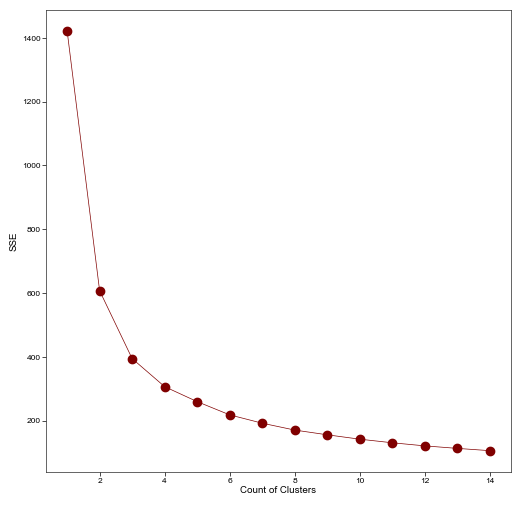

<Figure size 640x480 with 0 Axes>

In [2]:
###################################################################################

# import the cluster dataframe
loop_count_df = pd.read_csv(loop_count_file,sep='\t',header=0)

file_name = os.path.splitext(os.path.basename(loop_count_file))[0]
if '_loop_counts' in file_name: file_name = file_name.replace('_loop_counts','')

out_dir = os.path.dirname(loop_count_file) + '/' + file_name + '/cluster3'
os.makedirs(out_dir, exist_ok=True)

# extract the sample information from the column headers
data_cols = [i for i in loop_count_df.columns.tolist() if i not in ['chr1','x1','x2','chr2','y1','y2']]

#create an additional copy of the main dataframe, so that the og can be referenced later
loop_count_norm = loop_count_df.copy()

loop_count_norm = loop_count_norm[loop_count_norm[normalize_col] > filter] # keep only loops with balanced counts greater than the filter cutoff
loop_count_norm[data_cols] = loop_count_norm[data_cols].div(loop_count_norm[normalize_col], axis=0) # normalize to specified column
loop_count_norm[data_cols] = loop_count_norm[data_cols].fillna(0)

elbow(out_dir=out_dir,count_matrix=loop_count_norm,data_cols=data_cols)

Run Cluster 3.0

This normalizes the balanced counts based on the normalize_col and then uses subprocess to run Cluster 3.0

In [2]:
k_means = 6 #adjust based on the elbow plot

###################################################################################

# import the cluster dataframe
loop_count_df = pd.read_csv(loop_count_file,sep='\t',header=0)

file_name = os.path.splitext(os.path.basename(loop_count_file))[0]
if '_loop_counts' in file_name: file_name = file_name.replace('_loop_counts','')

out_dir = os.path.dirname(loop_count_file) + '/' + file_name + '/cluster3'
os.makedirs(out_dir, exist_ok=True)

# extract the sample information from the column headers
data_cols = [i for i in loop_count_df.columns.tolist() if i not in ['chr1','x1','x2','chr2','y1','y2']]

# convert coordinates to strings
loop_count_df['id'] = loop_count_df['chr1'] + '-' + loop_count_df['x1'].astype(str) + '-' + loop_count_df['x2'].astype(str) + '-' + loop_count_df['chr2'] + '-' + loop_count_df['y1'].astype(str) + '-' + loop_count_df['y2'].astype(str)

#create an additional copy of the main dataframe, so that the og can be referenced later
loop_count_norm = loop_count_df.copy()

loop_count_norm = loop_count_norm[loop_count_norm[normalize_col] > filter] # keep only loops with balanced counts greater than the filter cutoff
loop_count_norm[data_cols] = loop_count_norm[data_cols].div(loop_count_norm[normalize_col], axis=0) # normalize to specified column
loop_count_norm[data_cols] = loop_count_norm[data_cols].fillna(0)

# create directories to store the cluster output
fig_path = out_dir + '/k-' + str(k_means) + '/figures'
data_path = out_dir + '/k-' + str(k_means) + '/data'
os.makedirs(fig_path, exist_ok=True)
os.makedirs(data_path, exist_ok=True)

# save the id and data columns from the normalized dataframe to be used as input for clustering
loop_count_norm[['id'] + data_cols].to_csv(data_path + '/input_matrix.txt',sep='\t',header=True,index=False)

# run cluster3 as a subprocess
func = '~/apps/cluster-1.59/src/cluster -f ' + data_path + '/input_matrix.txt -r 100 -g 7 -k ' + str(k_means)
subprocess.call(func, shell=True)

# read back in the .kgg output file, then merge it with the input dataframe to identify the coordinates in each cluster
clusters = pd.read_csv(data_path + '/input_matrix_K_G' + str(k_means) + '.kgg',sep='\t',header=0)
clusters_df = clusters.merge(loop_count_df,on='id')
clusters_df = clusters_df.drop(labels='id', axis=1)

#re-name the clusters
replace_dict,cluster_order = sort_clusters(cluster_sort_df=clusters_df,
                                        data_cols=data_cols
                                        )
for word, replacement in replace_dict.items(): clusters_df['GROUP'] = clusters_df['GROUP'].replace(word, replacement)

clusters_df.to_csv(data_path + '/combined-clusters.txt',sep='\t',header=True,index=False)
clusters_df.reset_index(drop=True,inplace=True)

Cluster match

This takes pre-defined clusters from a prior run of Cluster 3.0 and matches the new data of interested to the same clusters. For example, taking the clusters defined based on the asynchronous Hi-C data and matching the data from mitotic exit to these clusters.

In [3]:
# use a different cluster file
# this would need to be generated using the same loop file as was used to make the matrix
cluster_file = '~/example_data/combined-clusters.txt'
cluster_file_name = 'RAD21_dep_async_clusters'

###################################################################################

# import the cluster dataframe
loop_count_df = pd.read_csv(loop_count_file,sep='\t',header=0)

# extract the sample information from the column headers
data_cols = [i for i in loop_count_df.columns.tolist() if i not in ['chr1','x1','x2','chr2','y1','y2']]

file_name = cluster_file_name + '_match'

out_dir = os.path.dirname(loop_count_file) + '/' + file_name + '/cluster3'
os.makedirs(out_dir, exist_ok=True)

# import the columns containing the coordinates and group information for the provided cluster file
use_clusters = pd.read_csv(cluster_file, sep='\t', header=0, usecols=[0,1,2,3,4,5,6])

clusters_df = use_clusters.merge(loop_count_df,on=['chr1','x1','x2','chr2','y1','y2'],how='inner')
clusters_df = clusters_df.fillna(0)

cluster_order = clusters_df['GROUP'].unique()

# Sort the original list based on numerical substrings
cluster_order = sorted(cluster_order, key=lambda s: int(re.findall(r'\d+', s)[0]))

# create directories to store the cluster output
fig_path = out_dir + '/' + file_name + '/figures'
data_path = out_dir + '/' + file_name + '/data'
os.makedirs(fig_path, exist_ok=True)
os.makedirs(data_path, exist_ok=True)

clusters_df.to_csv(data_path + '/combined-clusters.txt',sep='\t',header=True,index=False)


Cluster figures

This takes the clustered data, either from clustering or cluster match, and produces various figures from it. E.g. Fig 1d.

In [4]:
# prop will determine if the size of the subplots in the heatmap are proportional to the number of loops in the cluster
# I am sorry if this does not work very well....
prop = False

###################################################################################

comparison,treatments = comparison_type(data_cols=data_cols)
clusters_df.sort_values('GROUP',inplace=True,ascending=True)

#create an additional copy of the main dataframe, so that the og can be referenced later
clusters_norm = clusters_df.copy()

# determine the max value for each row, remove rows whereby the maximum is less than the given filter value (when doing cluster, not cluster-match), normalize to the max value, then replace NaN with 0
clusters_norm['max'] = clusters_norm[data_cols].max(axis=1)
clusters_norm[data_cols] = clusters_norm[data_cols].div(clusters_norm['max'], axis=0)
clusters_norm[data_cols] = clusters_norm[data_cols].fillna(0)
clusters_norm.drop('max',inplace=True,axis=1)

# This basically stacks the different samples on top of each other
info_cols = [x for x in clusters_norm.columns if x not in data_cols]
stacked_df = clusters_df.melt(id_vars=info_cols,value_vars=data_cols,var_name='treatment_group',value_name='balanced counts',ignore_index=True)
stacked_norm = clusters_norm.melt(id_vars=info_cols,value_vars=data_cols,var_name='treatment_group',value_name='max-normalized balanced counts',ignore_index=True)

stacked_df['treatment_group'] = stacked_df['treatment_group'].str.replace('_merge','')
stacked_norm['treatment_group'] = stacked_norm['treatment_group'].str.replace('_merge','')

if comparison == 'pairwise':
        # adjust the matrix to account for the pairwise comparison
        stacked_df[['treatment','time']] = stacked_df['treatment_group'].str.split('_',expand=True)
        stacked_norm[['treatment','time']] = stacked_norm['treatment_group'].str.split('_',expand=True)
        stacked_norm.drop('treatment_group',inplace=True,axis=1)
        stacked_df.drop('treatment_group',inplace=True,axis=1)

        box_xcol = 'time'
        box_hue_col = 'treatment'
        line_xcol = 'time'
        line_hue_col = 'treatment'
        line_add_n = 'subplot'
        other_add_n = 'subplot'
        line_subplots = True
        line_subplot_col = 'GROUP'
        line_palette = {}
        order = cluster_order
        for sample in stacked_df['treatment'].unique():
            if sample == 'DMSO': line_palette['DMSO'] = 'darkgrey'
            elif sample == 'dTAG': line_palette['dTAG'] = 'forestgreen'
            else: line_palette[sample] = randomize_hex()

palette = {'DMSO_merge': 'darkgrey',
        '4hr': 'mediumturquoise',
        '24hr': 'forestgreen',
        'DMSO':'darkgrey',
        'dTAG':'forestgreen'}

if comparison == 'multiple':
        box_xcol = 'GROUP'
        box_hue_col = 'treatment_group'
        line_xcol = 'treatment_group'
        line_subplots = False
        line_subplot_col = None
        line_add_n = 'hue_col'
        other_add_n = 'xcol'
        line_hue_col = 'GROUP'
        order = None
        line_palette = sns.color_palette("Paired", len(cluster_order))

        line_palette = {}
        for cluster in cluster_order: line_palette[cluster] = randomize_hex()

        for group in stacked_norm['treatment_group'].unique():
            if group not in palette.keys(): palette[group] = randomize_hex()

heat(count_matrix=clusters_norm,
        data_cols=data_cols,
        out_dir=fig_path,
        measure='max-normalized balanced counts',
        data_type='chromatin loops',
        title='',
        order=cluster_order,
        subplot_col='GROUP',
        subplots=True,
        out_name='heatmap',
        proportional=prop,
        add_n=True)

line(melted_df=stacked_norm,
        ycol='max-normalized balanced counts',
        xcol=line_xcol,
        hue_col=line_hue_col,
        out_dir=fig_path,
        ycol_measure='max-normalized balanced counts',
        xcol_measure=None,
        title='',
        out_name='lineplot',
        palette=line_palette,
        subplots = line_subplots,
        subplot_col=line_subplot_col,
        sharey=False,
        Y_range=[0,1],
        add_n=line_add_n,
        order=order
        )

strip(melted_df=stacked_df,
        ycol='balanced counts',
        xcol=box_xcol,
        out_dir=fig_path,
        measure='balanced counts',
        title='',
        out_name='stripplot',
        sharey=False,
        Y_range=[0,1],
        hue_col=box_hue_col,
        subplots=line_subplots,
        subplot_col=line_subplot_col,
        palette=palette,
        add_n=other_add_n,
        order=order
        )

box(melted_df=stacked_df,
        ycol='balanced counts',
        xcol=box_xcol,
        out_dir=fig_path,
        measure='balanced counts',
        title='',
        out_name='boxplot',
        sharey=False,
        Y_range=[0,0.4],
        hue_col=box_hue_col,
        subplots=line_subplots,
        subplot_col=line_subplot_col,
        palette=palette,
        add_n=other_add_n,
        order=order
        )


<Figure size 640x480 with 0 Axes>